# Stock Price Prediction Using Python and ML

## Import required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import yfinance as yf
import joblib

## Download Stock Data

In [2]:
stock = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


## Check Dataset

In [4]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [5]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899567,149.680872,151.223470,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163704,55.160702,51.324800,55.059313,2.323470e+07
25%,126.279102,127.397079,124.278508,125.724400,5.546825e+07
50%,149.968628,151.709750,148.037194,149.788890,7.628335e+07
75%,175.902012,177.452448,174.337234,175.708227,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [6]:
stock.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

## Visualize Price

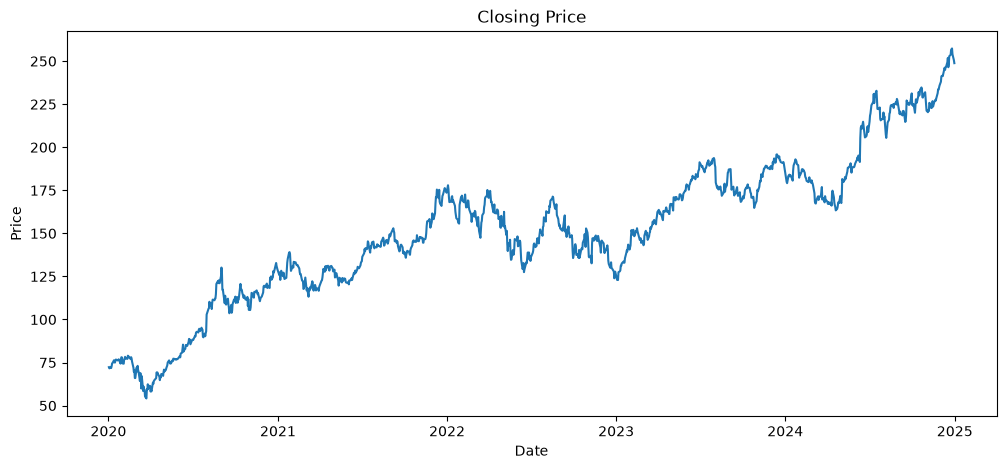

In [11]:
plt.figure(figsize=(12,5))
plt.plot(stock['Close'])
plt.title("Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

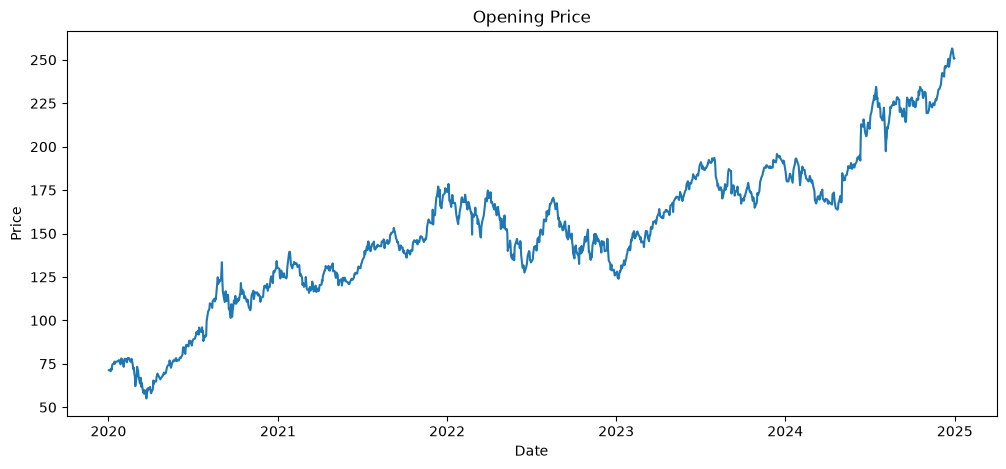

In [12]:
plt.figure(figsize=(12,5))
plt.plot(stock['Open'])
plt.title("Opening Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Create Features

In [14]:
# Create a column for tomorrow's closing price
stock['Target'] = stock['Close'].shift(-1)

In [15]:
stock.dropna(inplace=True)

## Select Features

In [16]:
x = stock[['Open', 'High', 'Low', 'Close', 'Volume']]
y = stock['Target']

In [17]:
x

Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,


In [18]:
y

Series([], Name: Target, dtype: float64)